### Load & Merge Dataset

In [1]:
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
fpath = "data"

files = [f for f in os.listdir(fpath) if f.endswith('.csv')]

df_list = []
for f in files:
    df = pd.read_csv(os.path.join(fpath, f))
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

print("Shape:", data.shape)

Shape: (2830743, 79)


### Cleaning

In [5]:
import numpy as np

data.columns = data.columns.str.strip()
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

### Label Encoding

In [7]:
data['Label'] = data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print(data['Label'].value_counts())

Label
0    2271320
1     556556
Name: count, dtype: int64


Features + Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Label'])
y = data['Label']

X = X.select_dtypes(include=[np.number])

sc = StandardScaler()
X_sc = sc.fit_transform(X)

### Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2262300, 78)
Test: (565576, 78)


### Helper Function

In [13]:
def convert_preds(preds):
    return np.where(preds == -1, 1, 0)

In [15]:
res = {}

## Tabular Approach

## Models:
### Isolation Forest

In [17]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import IsolationForest

In [19]:
ifm = IsolationForest(contamination=0.15, random_state=42)
ifm.fit(X_train)

p_if = convert_preds(ifm.predict(X_test))

print("Isolation Forest")
print(classification_report(y_test, p_if))

res["IF_Tabular"] = {
    "Accuracy": accuracy_score(y_test, p_if),
    "Precision": precision_score(y_test, p_if),
    "Recall": recall_score(y_test, p_if),
    "F1": f1_score(y_test, p_if)
}

Isolation Forest
              precision    recall  f1-score   support

           0       0.86      0.91      0.88    454265
           1       0.49      0.38      0.43    111311

    accuracy                           0.80    565576
   macro avg       0.67      0.64      0.65    565576
weighted avg       0.78      0.80      0.79    565576



### One-Class SVM

In [21]:
from sklearn.svm import OneClassSVM

In [23]:
ocsvm = OneClassSVM(kernel='rbf', gamma='scale')
ocsvm.fit(X_train[:5000])  

p_ocsvm = convert_preds(ocsvm.predict(X_test))

print("OCSVM")
print(classification_report(y_test, p_ocsvm))

res["OCSVM"] = {
    "Accuracy": accuracy_score(y_test, p_ocsvm),
    "Precision": precision_score(y_test, p_ocsvm),
    "Recall": recall_score(y_test, p_ocsvm),
    "F1": f1_score(y_test, p_ocsvm)
}

OCSVM
              precision    recall  f1-score   support

           0       0.84      0.52      0.64    454265
           1       0.23      0.59      0.33    111311

    accuracy                           0.54    565576
   macro avg       0.54      0.56      0.49    565576
weighted avg       0.72      0.54      0.58    565576



### Elliptic Envelope

In [25]:
from sklearn.covariance import EllipticEnvelope

In [27]:
ee = EllipticEnvelope(contamination=0.15, random_state=42)
ee.fit(X_train[:5000])

p_ee = convert_preds(ee.predict(X_test))

print("Elliptic Envelope")
print(classification_report(y_test, p_ee))

res["EE"] = {
    "Accuracy": accuracy_score(y_test, p_ee),
    "Precision": precision_score(y_test, p_ee),
    "Recall": recall_score(y_test, p_ee),
    "F1": f1_score(y_test, p_ee)
}

Elliptic Envelope
              precision    recall  f1-score   support

           0       0.84      0.89      0.86    454265
           1       0.40      0.30      0.34    111311

    accuracy                           0.77    565576
   macro avg       0.62      0.59      0.60    565576
weighted avg       0.75      0.77      0.76    565576



### LOF tabular

In [29]:
from sklearn.neighbors import LocalOutlierFactor

In [31]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.15, novelty=True)
lof.fit(X_train[:10000])

p_lof = convert_preds(lof.predict(X_test))

p_lof = [1 if x == -1 else 0 for x in p_lof]

print("LOF:")
print(classification_report(y_test, p_lof))

res["LOF_Tabular"] = {
    "Accuracy": accuracy_score(y_test, p_lof),
    "Precision": precision_score(y_test, p_lof),
    "Recall": recall_score(y_test, p_lof),
    "F1": f1_score(y_test, p_lof)
}

LOF:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89    454265
           1       0.00      0.00      0.00    111311

    accuracy                           0.80    565576
   macro avg       0.40      0.50      0.45    565576
weighted avg       0.65      0.80      0.72    565576



### Autoencoder

In [33]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [35]:
inp_dim = X_train.shape[1]

inp_layer = Input(shape=(inp_dim,))

enc = Dense(32, activation="relu")(inp_layer)
enc = Dense(16, activation="relu")(enc)

dec = Dense(32, activation="relu")(enc)
dec = Dense(inp_dim, activation="linear")(enc)

aenc = Model(inputs=inp_layer, outputs=dec)

aenc.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

aenc.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 78)             │         1,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382 (17.12 KB)

 Trainable params: 4,382 (17.12 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
X_train_n = X_train[y_train == 0]

history = aenc.fit(
    X_train_n,
    X_train_n,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 4s 480us/step - loss: 0.4024 - val_loss: 0.1084
Epoch 2/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 427us/step - loss: 0.2576 - val_loss: 0.1086
Epoch 3/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 426us/step - loss: 0.1690 - val_loss: 0.0972
Epoch 4/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 429us/step - loss: 0.1794 - val_loss: 0.1117
Epoch 5/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 430us/step - loss: 0.1885 - val_loss: 0.0955
Epoch 6/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 433us/step - loss: 0.2784 - val_loss: 0.0970
Epoch 7/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 436us/step - loss: 0.1511 - val_loss: 0.0991
Epoch 8/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 425us/step - loss: 0.1585 - val_loss: 0.1013
Epoch 9/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 438us/step - loss: 0.1444 - val_loss: 0.0952
Epoch 10/10
6389/6389 ━━━━━━━━━━━━━━━━━━━━ 3s 433us/step - loss: 0.1744 - val_loss: 0.0968


In [39]:
X_test_p = aenc.predict(X_test)

recons_err = np.mean(
    np.power(X_test - X_test_p, 2),
    axis=1
)

17675/17675 ━━━━━━━━━━━━━━━━━━━━ 4s 213us/step


In [41]:
th = np.percentile(recons_err, 85)

pred_ae = (recons_err > th).astype(int)

In [43]:
print("Autoencoder")
print(classification_report(y_test, pred_ae))

res["Autoencoder"] = {
    "Accuracy": accuracy_score(y_test, pred_ae),
    "Precision": precision_score(y_test, pred_ae),
    "Recall": recall_score(y_test, pred_ae),
    "F1": f1_score(y_test, pred_ae)
}

Autoencoder
              precision    recall  f1-score   support

           0       0.88      0.93      0.91    454265
           1       0.64      0.48      0.55    111311

    accuracy                           0.84    565576
   macro avg       0.76      0.71      0.73    565576
weighted avg       0.83      0.84      0.84    565576



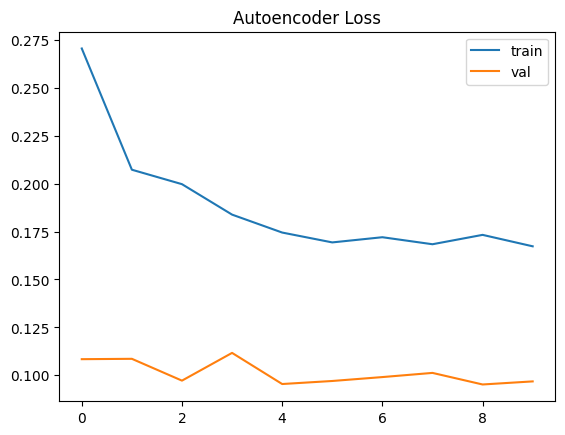

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Autoencoder Loss")
plt.legend()
plt.show()

## Graph-based Approach

### Subset

In [47]:
subset_size = 5000  

X_gr = X_sc[:subset_size]
y_gr = y[:subset_size]

### Train-test split

In [49]:
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_gr, y_gr, test_size=0.2, random_state=42, stratify=y_gr
)

### Build k-NN graph

In [51]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

In [53]:
k = 10  

nbrs = NearestNeighbors(n_neighbors=k, n_jobs=-1)
nbrs.fit(Xg_train)

distances, indices = nbrs.kneighbors(Xg_train)

G = nx.Graph()


for i in range(len(Xg_train)):
    G.add_node(i)

for i in range(len(Xg_train)):
    for j_idx, j in enumerate(indices[i]):
        if i != j:
            weight = 1 / (distances[i][j_idx] + 1e-5)  
            G.add_edge(i, j, weight=weight)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 4000
Edges: 23753


In [55]:
degree = np.array([val for (node, val) in G.degree()])
clustering = np.array(list(nx.clustering(G).values()))
graph_features = np.vstack((degree, clustering)).T

In [57]:
from sklearn.decomposition import PCA

pca_gr = PCA(n_components=10)
X_gr_pca = pca_gr.fit_transform(X_gr)

## Models:
### Isolation Forest (Graph-based)

In [59]:
if_gr = IsolationForest(contamination=0.15, random_state=42)
if_gr.fit(X_gr_pca)

if_p_gr = convert_preds(if_gr.predict(X_gr_pca))

print("IF (Graph):")
print(classification_report(y_gr, if_p_gr))

res["IF_Graph"] = {
    "Accuracy": accuracy_score(y_gr, if_p_gr),
    "Precision": precision_score(y_gr, if_p_gr, zero_division=0),
    "Recall": recall_score(y_gr, if_p_gr, zero_division=0),
    "F1": f1_score(y_gr, if_p_gr, zero_division=0)
}

IF (Graph):
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      5000
           1       0.00      0.00      0.00         0

    accuracy                           0.85      5000
   macro avg       0.50      0.43      0.46      5000
weighted avg       1.00      0.85      0.92      5000



### LOF (Graph-based)

In [61]:
lof_gr = LocalOutlierFactor(
    n_neighbors=10,
    contamination=0.15,
    novelty=True
)

lof_gr.fit(X_gr_pca)

lof_p_gr = convert_preds(lof_gr.predict(X_gr_pca))

print("LOF (Graph):")
print(classification_report(y_gr, lof_p_gr))

res["LOF_Graph"] = {
    "Accuracy": accuracy_score(y_gr, lof_p_gr),
    "Precision": precision_score(y_gr, lof_p_gr, zero_division=0),
    "Recall": recall_score(y_gr, lof_p_gr, zero_division=0),
    "F1": f1_score(y_gr, lof_p_gr, zero_division=0)
}

LOF (Graph):
              precision    recall  f1-score   support

           0       1.00      0.88      0.93      5000
           1       0.00      0.00      0.00         0

    accuracy                           0.88      5000
   macro avg       0.50      0.44      0.47      5000
weighted avg       1.00      0.88      0.93      5000



In [63]:
results_df = pd.DataFrame(res).T  # transpose for clean view
results_df = results_df.round(3)

results_df

,Accuracy,Precision,Recall,F1
IF_Tabular,0.801,0.493,0.375,0.426
OCSVM,0.536,0.232,0.588,0.333
EE,0.774,0.400,0.299,0.342
LOF_Tabular,0.803,0.000,0.000,0.000
Autoencoder,0.844,0.636,0.484,0.550
IF_Graph,0.850,0.000,0.000,0.000
LOF_Graph,0.877,0.000,0.000,0.000


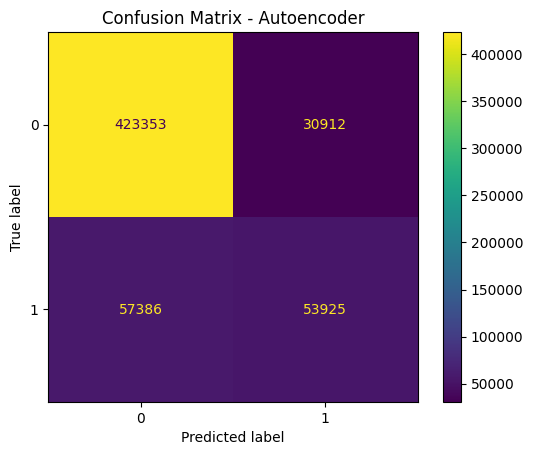

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred_ae)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Autoencoder")
plt.show()

Explained variance: [0.45745775 0.13218279]
Total: 0.5896405420068325


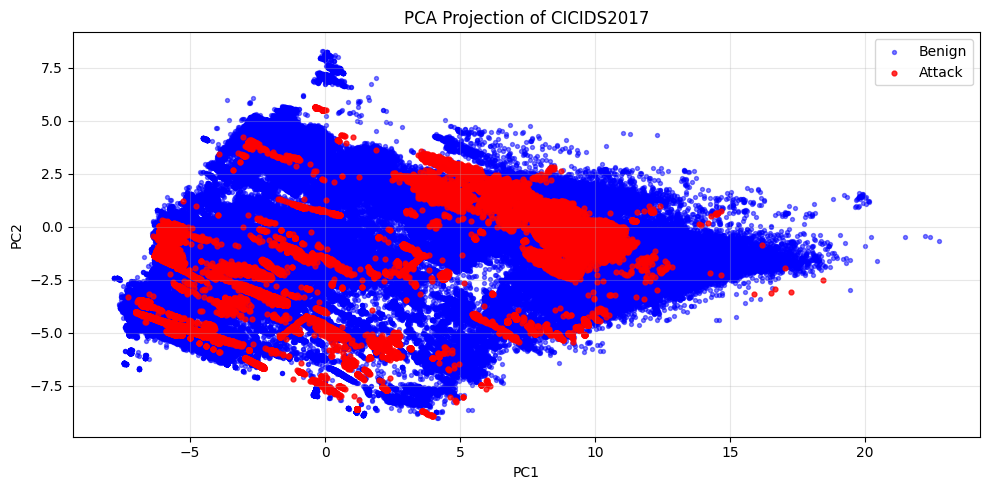

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# If X is DataFrame
X_clean = X.copy()

# Replace inf and -inf with NaN
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median
X_clean = X_clean.fillna(X_clean.median())

# Convert to numeric just in case
X_clean = X_clean.astype(float)

# Optional log transform for skewed CICIDS features
X_log = np.log1p(np.abs(X_clean))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Variance
print("Explained variance:", pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(10,5))

plt.scatter(
    X_pca[y==0,0], X_pca[y==0,1],
    c="blue", s=8, alpha=0.5, label="Benign"
)

plt.scatter(
    X_pca[y==1,0], X_pca[y==1,1],
    c="red", s=12, alpha=0.8, label="Attack"
)

plt.title("PCA Projection of CICIDS2017")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()